In [1]:
import sys, os
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/final/reconstruction")
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from tensorflow_probability.substrates import jax as tfp
# Import JAX and require double precision.
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
dtype = jnp.float64

# Other tools.
from scipy.interpolate import griddata
from lib.gupta import precompute_fixed_grid
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
# Import TriplePandel stuff
from lib.simdata_i3 import I3SimHandler
from lib.geo import center_track_pos_and_time_based_on_data
from lib.gupta_network_eqx_4comp import get_network_eval_v_fn, get_network_eval_v_fn_f32
from lib.experimental_methods import get_vertex_seeds
from lib.linefit import linefit_3d_time_np, linefit_3d_time_jnp
from fitting.llh_scanner import get_scanner
from fitting.llh_fitter import get_fitter
from dom_track_eval import get_eval_network_doms_and_track
from likelihood_conv_mpe_logsumexp_gupta import get_neg_c_triple_gamma_llh, get_neg_c_triple_gamma_llh_optimized
from likelihood_conv_mpe_w_noise_logsumexp_gupta import get_neg_c_triple_gamma_llh_SRT_noise
from astropy.coordinates import SkyCoord
# A custom color scheme
from palettable.cubehelix import Cubehelix
cx = Cubehelix.make(start=0.3, rotation=-0.5, n=16, reverse=False, gamma=1.0,
     	max_light=1.0,max_sat=0.5, min_sat=1.4).get_mpl_colormap()
import astropy.units as u
# Specify the grid.
dzen = 0.05 # rad
dazi = 0.05 # rad
n_eval = 25 # number of grid points per axes


# Assume 4-component gupta by default
n_hidden = 96
gupta = True
n_comp = 4

2026-05-19 17:55:12.788994: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def get_event_data(event_index: int) -> pd.DataFrame:
    ev_idx = event_index
    event_meta = events_meta.iloc[ev_idx]
    print(event_meta)
    event_id = event_meta['event_id']
    
    event_data = events_data[events_data['event_id'] == event_id].copy()
    return event_meta, event_data
def get_per_dom_summary_from_sim_data(
    meta: pd.DataFrame,
    pulses: pd.DataFrame,
    charge_key='charge',
    correct_charge=False) -> pd.DataFrame:

    df_qtot = pulses[['sensor_id', charge_key]].groupby(by=['sensor_id'], as_index=False).sum()
    df_tmin = pulses[['sensor_id', 'time']].groupby(by=['sensor_id'], as_index=False).min()
    df = df_qtot.merge(geo.iloc[df_qtot['sensor_id']], on='sensor_id', how='outer')
    df['time'] = df_tmin['time'].values

    if correct_charge == True:
        df_corr = pulses[['sensor_id', 'charge_correction']].groupby(by=['sensor_id'], as_index=False).mean()
        df['charge'] = df['charge'].values * df_corr['charge_correction'].values

    if charge_key != 'charge':
        df.rename({charge_key: 'charge'}, inplace=True, axis='columns')
    return df
def replace_early_pulse(summary_data, pulses):
    corrected_time = np.zeros(len(summary_data))
    for i, row in summary_data.iterrows():
        s_id = row['sensor_id']
        q_tot = row['charge']
        t1 = row['time']

        idx = pulses['sensor_id'] == s_id
        pulses_this_dom = pulses[idx]
        corrected_time[i] = get_first_regular_pulse(pulses_this_dom, t1, q_tot)



    summary_data['time'] = corrected_time
    return summary_data

def get_first_regular_pulse(pulses, t1, q_tot, crit_delta=10, crit_ratio = 5.e-3, crit_charge=100.):
    # technically, if we do remove early pulses, one could correct the total charge.
    # in practice, this would be an epsilon correction. Not worth adding the extra code complexity.
    # calculate ratio of charge within 10ns and 75ns of hit.
    if q_tot < crit_charge:
        return t1

    n = len(pulses)
    charge = pulses['charge'].to_numpy()
    time = pulses['time'].to_numpy()
    crit_delta_long = 75

    j = 0 # pts to end of crit_delta interval
    k = 0 # pts to end of crit_delta_long interval
    q_veto = 0
    q_long = 0
    for i in range(0, n):
        crit_time = time[i] + crit_delta
        if j < i:
            j = i

        # extend window
        while j < n and time[j] < crit_time:
            q_veto += charge[j]
            j += 1

        crit_time = time[i] + crit_delta_long
        if k < i:
            k = i

        # extend window
        while k < n and time[k] < crit_time:
            q_long += charge[k]
            k += 1

        r_veto = q_veto / q_long
        if r_veto > crit_ratio:
            # found a reasonable pulse
            # break
            break

        # remove early pulse
        q_long -= charge[i]
        q_veto -= charge[i]

    return time[i]

def plot_event(df, index, geo=None, outfile=None, plot_pdf=None):
    fig = plt.figure(figsize=(12,8))
    ax = plt.subplot(projection='3d')
    ax.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
    ax.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
    ax.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)

    try:
        im = ax.scatter(geo['x'], geo['y'], geo['z'], s=0.9, c='0.7', alpha=0.8)
    except:
        pass

    im = ax.scatter(df['x'], df['y'], df['z'], s=np.sqrt(df['charge']*100), c=df['time'],
                    cmap='rainbow_r',  edgecolors='k', zorder=1000)
    ax.view_init(elev=0, azim=90)
    ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
    cb = plt.colorbar(im, orientation="vertical", pad=0.1)
    cb.set_label(label='time [ns]', size='x-large')
    cb.ax.tick_params(labelsize='x-large')
    plt.title(f'Event {index}')
    
    if plot_pdf:
        pdf.savefig()
        plt.close()
    else:
        plt.show()
    # if outfile is None:
    #     plt.show()

    # else:
    #     plt.savefig(outfile, dpi=300)


In [3]:
def direction_to_zenith_azimuth(dx, dy, dz):
    """Convert direction vector to (zenith, azimuth) angles (IceCube convention).
    
    zenith: angle from downward direction (0 = down, π/2 = horizontal, π = up)
    azimuth: angle in xy-plane (0 = north, π/2 = west, π = south, 3π/2 = east)
    """
    norm = np.sqrt(dx**2 + dy**2 + dz**2) + 1e-8  # FIXED: was dx2 + dy2
    dx, dy, dz = dx / norm, dy / norm, dz / norm
    zenith = np.arccos(-dz)  # IceCube convention
    azimuth = (np.arctan2(dy, dx) + np.pi) % (2 * np.pi)
    return np.array([zenith, azimuth])

def linefit_3d_time_np_weighted(fitting_event_data: pd.DataFrame, weight_by_charge=True, 
                                 sort_by_time=True, verbose=False):
    """Weighted linefit that can use hit charge as quality weight.
    
    Args:
        fitting_event_data: DataFrame with columns [sensor_id, charge, x, y, z, time]
        weight_by_charge: If True, weights by charge (hits with more charge are more reliable)
        sort_by_time: If True, sorts by time before fitting
        verbose: Print diagnostic information
    
    Returns:
        r0, t0, v, direction: Same as linefit_3d_time_np
    """
    
    data = fitting_event_data.copy()
    
    if sort_by_time:
        data = data.sort_values('time').reset_index(drop=True)
    
    positions = data.values[:, 2:5]
    times = data.values[:, 5]
    charges = data.values[:, 1]
    
    # Get weights
    if weight_by_charge:
        weights = np.maximum(charges, 0.6)  # Don't allow zero weight
        weights = weights / np.sum(weights)  # Normalize
        if verbose:
            print(f"Using charge-weighted fit (mean charge: {np.mean(charges):.3f})")
    else:
        weights = np.ones_like(times) / len(times)
        if verbose:
            print("Using unweighted fit")
    
    if verbose:
        print(f"Number of hits: {len(data)}")
        print(f"Time range: {times.min():.1f} to {times.max():.1f}")
    
    # Weighted mean-centering
    mean_pos = np.average(positions, axis=0, weights=weights)
    mean_time = np.average(times, weights=weights)
    
    delta_pos = positions - mean_pos
    delta_time = times - mean_time
    
    # Weighted least squares
    W = np.diag(weights)
    numerator = np.dot(delta_pos.T, W @ delta_time)
    denominator = np.dot(delta_time, W @ delta_time) + 1e-8
    v = numerator / denominator
    
    t0 = mean_time
    r0 = mean_pos
    
    direction = direction_to_zenith_azimuth(*v)
    
    t0 = jnp.asarray(t0)
    r0 = np.asarray(r0, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    direction = jnp.asarray(direction)
    
    return r0, t0, v, direction


def linefit_3d_time_np(fitting_event_data: pd.DataFrame):
    positions = fitting_event_data.values[:, 2:5]
    times = fitting_event_data.values[:, 5]

    """
    Perform a linefit in 3D space with time (NumPy version).
    Args:
        positions: Array of shape (N, 3) with (x, y, z) positions.
        times: Array of shape (N) with corresponding time values.
    Returns:
        r0: Fitted position at t0 (mean time).
        v: Velocity vector (direction and speed).
        direction: (zenith, azimuth)
    """

    # Mean-center the data
    mean_pos = np.mean(positions, axis=0)
    mean_time = np.mean(times)

    # Subtract means
    delta_pos = positions - mean_pos
    delta_time = times - mean_time

    # Least squares: v = (delta_pos^T delta_time) / (delta_time^T delta_time)
    numerator = np.dot(delta_pos.T, delta_time)          # shape (3,)
    denominator = np.dot(delta_time, delta_time) + 1e-8  # scalar
    v = numerator / denominator

    t0 = mean_time
    r0 = mean_pos
    

    def direction_to_zenith_azimuth(dx, dy, dz):
        """Convert a direction vector to (zenith, azimuth) angles."""
        norm = np.sqrt(dx**2 + dy**2 + dz**2) + 1e-8
        dx, dy, dz = dx / norm, dy / norm, dz / norm
        zenith = np.arccos(-dz)   # IceCube convention
        azimuth = (np.arctan2(dy, dx) + np.pi) % (2 * np.pi)
        return np.array([zenith, azimuth])

    direction = direction_to_zenith_azimuth(*v)
    t0 = jnp.asarray(t0)
    r0 = np.asarray(r0, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    direction = jnp.asarray(direction)

    return r0, t0, v, direction

def linefit(fitting_event_data: pd.DataFrame):
    """
    Perform a charge-weighted linefit in 3D space with time (NumPy version).
    Args:
        fitting_event_data: DataFrame with columns [sensor_id, charge, x, y, z, time]
    Returns:
        r0: Fitted position at t0 (mean time).
        t0: Mean (charge-weighted) time.
        v: Velocity vector (direction and speed).
        direction: (zenith, azimuth) in radians.
    """
    positions = fitting_event_data.values[:, 2:5].astype(np.float64)  # (x, y, z)
    times     = fitting_event_data.values[:, 5].astype(np.float64)    # time
    charges   = fitting_event_data.values[:, 1].astype(np.float64)    # charge weights

    # Normalize weights so they sum to 1
    w = charges / (charges.sum() + 1e-8)                              # shape (N,)
    
    # Charge-weighted means
    mean_pos  = np.average(positions, axis=0, weights=w)              # shape (3,)
    mean_time = np.average(times, weights=w)                          # scalar

    # Subtract weighted means
    delta_pos  = positions - mean_pos                                 # (N, 3)
    delta_time = times - mean_time                                    # (N,)

    # Weighted least squares: v = (w * delta_pos)^T delta_time / (w * delta_time^T delta_time)
    numerator   = np.dot((w[:, None] * delta_pos).T, delta_time)   # w[:, None] -> (N,1) broadcasts correctly
    denominator = np.dot(w * delta_time, delta_time) + 1e-8
    v  = numerator / denominator
    t0 = mean_time
    r0 = mean_pos

    def direction_to_zenith_azimuth(dx, dy, dz):
        """Convert a direction vector to (zenith, azimuth) angles (IceCube convention)."""
        norm = np.sqrt(dx**2 + dy**2 + dz**2) + 1e-8
        dx, dy, dz = dx / norm, dy / norm, dz / norm
        zenith  = np.arccos(-dz)
        azimuth = (np.arctan2(dy, dx) + np.pi) % (2 * np.pi)
        return np.array([zenith, azimuth])

    direction = direction_to_zenith_azimuth(*v)

    t0        = jnp.float64(t0)
    r0        = np.asarray(r0,        dtype=np.float64)
    v         = np.asarray(v,         dtype=np.float64)
    direction = np.asarray(direction, dtype=np.float64)

    return r0, t0, v, direction

def get_multiple_linefit_seeds(event_data, n_seeds=5):
    """Generate multiple seed candidates for low-charge events."""
    seeds = []
    
    # Standard weighted fit
    r0, t0, v, direction = linefit_3d_time_np_weighted(event_data, weight_by_charge=True)
    seeds.append(('weighted', r0, t0, direction))
    
    # Unweighted fit
    r0, t0, v, direction = linefit_3d_time_np_weighted(event_data, weight_by_charge=False)
    seeds.append(('unweighted', r0, t0, direction))
    
    # High-charge-only fit (use top N% of hits)
    if len(event_data) > 3:
        charge_threshold = np.percentile(event_data['charge'], 75)
        high_charge_data = event_data[event_data['charge'] >= charge_threshold]
        if len(high_charge_data) > 2:
            r0, t0, v, direction = linefit_3d_time_np_weighted(high_charge_data, weight_by_charge=True)
            seeds.append(('high_charge_only', r0, t0, direction))
    
    # Early hits only (first 50% in time)
    if len(event_data) > 2:
        time_threshold = np.percentile(event_data['time'], 50)
        early_data = event_data[event_data['time'] <= time_threshold]
        if len(early_data) > 2:
            r0, t0, v, direction = linefit_3d_time_np_weighted(early_data, weight_by_charge=True)
            seeds.append(('early_hits', r0, t0, direction))
    
    return seeds


def pick_best_seed(seeds, neg_llh, fitting_event_data, threshold_charge=30):
    """Quick likelihood evaluation to pick best seed."""
    best_seed = seeds[0]  # fallback
    best_llh = np.inf
    
    for name, pos, time, direction in seeds:
        try:
            llh = neg_llh(direction, pos, time, fitting_event_data)
            if llh < best_llh:
                best_llh = llh
                best_seed = (name, pos, time, direction)
        except:
            continue
    
    return best_seed

def zenith_to_declination(zenith_deg):
    """
    Convert zenith (polar angle from +z, degrees) → declination.
      dec = 90° - zenith
    Valid zenith range: [0°, 180°] → dec range: [+90°, -90°]
    Values outside [0°,180°] indicate upstream wrapping issues in the data.
    We wrap zenith into [0°,180°] before converting.
    """
    zen = np.asarray(zenith_deg, dtype=float)
    # Wrap into [0°, 360°] then fold upper half back
    zen = zen % 360.0
    zen = np.where(zen > 180.0, 360.0 - zen, zen)
    return 90.0 - zen

def angular_sep_deg(az1, zen1, az2, zen2):
    """Great-circle separation. zen = polar angle from +z (degrees)."""
    lat1 = zenith_to_declination(zen1)
    lat2 = zenith_to_declination(zen2)
    # Wrap azimuth into [0°, 360°]
    az1 = np.asarray(az1) % 360.0
    az2 = np.asarray(az2) % 360.0
    
    c1 = SkyCoord(az1 * u.deg, lat1 * u.deg, frame="icrs")
    c2 = SkyCoord(az2 * u.deg, lat2 * u.deg, frame="icrs")
    return c1.separation(c2).deg



In [4]:
def plot_event_new(
    df,
    index,
    geo=None,
    outfile=None,
    plot_pdf=None,
    seed_pos=None,
    seed_time=None,
    seed_direction=None,
    track_length=500,
    azims=(90, 0),   # two azimuth viewing angles
    elev=0
):
    """
    Plot event with detector geometry, hits, and optionally the seed track.
    Creates two 3D subplots with different azimuth viewing angles.

    Args:
        df: DataFrame with hit data [x, y, z, charge, time]
        index: Event index for title
        geo: DataFrame with detector geometry [x, y, z]
        outfile: Output file path
        plot_pdf: PDF object to save figure to
        seed_pos: (3,) array with seed vertex position [x, y, z]
        seed_time: Scalar seed time
        seed_direction: (2,) array with [zenith, azimuth] in radians
        track_length: Length of track line to draw in meters
        azims: Tuple of azimuth angles for the two subplots
        elev: Elevation viewing angle
    """

    fig = plt.figure(figsize=(12, 8))

    axes = [
        fig.add_subplot(1, 2, 1, projection='3d'),
        fig.add_subplot(1, 2, 2, projection='3d')
    ]

    for i, ax in enumerate(axes):

        ax.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
        ax.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
        ax.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)

        # Plot detector geometry
        try:
            ax.scatter(
                geo['x'],
                geo['y'],
                geo['z'],
                s=0.9,
                c='0.7',
                alpha=0.8
            )
        except:
            pass

        # Plot hits
        im = ax.scatter(
            df['x'],
            df['y'],
            df['z'],
            s=np.sqrt(df['charge'] * 100),
            c=df['time'],
            cmap='rainbow_r',
            edgecolors='k',
            zorder=1000
        )

        # Plot seed track if provided
        if seed_pos is not None and seed_direction is not None:

            zenith, azimuth = float(seed_direction[0]), float(seed_direction[1])

            dx = np.sin(zenith) * np.cos(azimuth)
            dy = np.sin(zenith) * np.sin(azimuth)
            dz = np.cos(zenith)

            norm = np.sqrt(dx**2 + dy**2 + dz**2)

            if norm > 0:
                dx, dy, dz = dx / norm, dy / norm, dz / norm

            t_vals = np.linspace(-track_length / 2, track_length / 2, 100)

            track_x = seed_pos[0] + dx * t_vals
            track_y = seed_pos[1] + dy * t_vals
            track_z = seed_pos[2] + dz * t_vals

            ax.plot(
                track_x,
                track_y,
                track_z,
                'r-',
                linewidth=3,
                label='Seed Track',
                zorder=500,
                alpha=0.8
            )

            ax.scatter(
                *seed_pos,
                s=400,
                c='red',
                marker='*',
                edgecolors='darkred',
                linewidth=2,
                zorder=1001,
                label='Seed Vertex'
            )

        # Set different viewing angle
        ax.view_init(elev=elev, azim=azims[i])

        ax.tick_params(
            axis='both',
            which='both',
            width=1.5,
            colors='0.0',
            labelsize=16
        )

        ax.set_title(f'Event {index} | azim={azims[i]}')

        if geo is not None:
            ax.set_xlim(np.min(geo['x']), np.max(geo['x']))
            ax.set_ylim(np.min(geo['y']), np.max(geo['y']))
            ax.set_zlim(np.min(geo['z']), np.max(geo['z']))

        if seed_pos is not None:
            plt.legend(loc='upper left', fontsize=12)

    # cb = fig.colorbar(
    # im,
    # ax=axes,
    # orientation="horizontal",
    # pad=0.08,      # distance from plots
    # fraction=0.035, # thickness of colorbar
    # shrink=0.55,    # overall length
    # aspect=35       # long and thin
    # )

    # cb.set_label(label='time [ns]', size='large')
    # cb.ax.tick_params(labelsize='large')
    
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, bbox_inches='tight')

    if plot_pdf is not None:
        plot_pdf.savefig(fig)

    plt.show()

In [12]:
def angular_separation_deg(z1_deg, a1_deg, z2_deg, a2_deg):

    z1 = np.radians(z1_deg)
    a1 = np.radians(a1_deg)

    z2 = np.radians(z2_deg)
    a2 = np.radians(a2_deg)

    cos_sep = (
        np.cos(z1) * np.cos(z2)
        + np.sin(z1) * np.sin(z2) * np.cos(a1 - a2)
    )

    cos_sep = np.clip(cos_sep, -1, 1)

    return np.degrees(np.arccos(cos_sep))


In [56]:
EVENT_INDEX=14
PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22646/tfrecords/ftr/'
META_FILE_NAME = 'meta_ds_22646_from_0_to_1000_10_to_100TeV.ftr'
PULSES_FILE_NAME = 'pulses_ds_22646_from_0_to_1000_10_to_100TeV.ftr'

event_id                   226460000130097.0
idx_start                                0.0
idx_end                                 55.0
n_channel_HLC                           27.0
neutrino_energy                  4918.429182
muon_energy                      3968.380481
muon_energy_at_detector          1400.539583
muon_energy_lost                  760.660298
q_tot                                  50.25
n_channel                               38.0
muon_zenith                         2.326394
muon_azimuth                        3.349811
muon_time                        4638.175565
muon_pos_x                      -1439.562769
muon_pos_y                       -337.110505
muon_pos_z                      -1529.024954
spline_mpe_zenith                   2.332129
spline_mpe_azimuth                  3.351723
spline_mpe_time                 10886.745892
spline_mpe_pos_x                 -106.030986
spline_mpe_pos_y                   -55.52435
spline_mpe_pos_z                  -243.51177
Name: 14, 

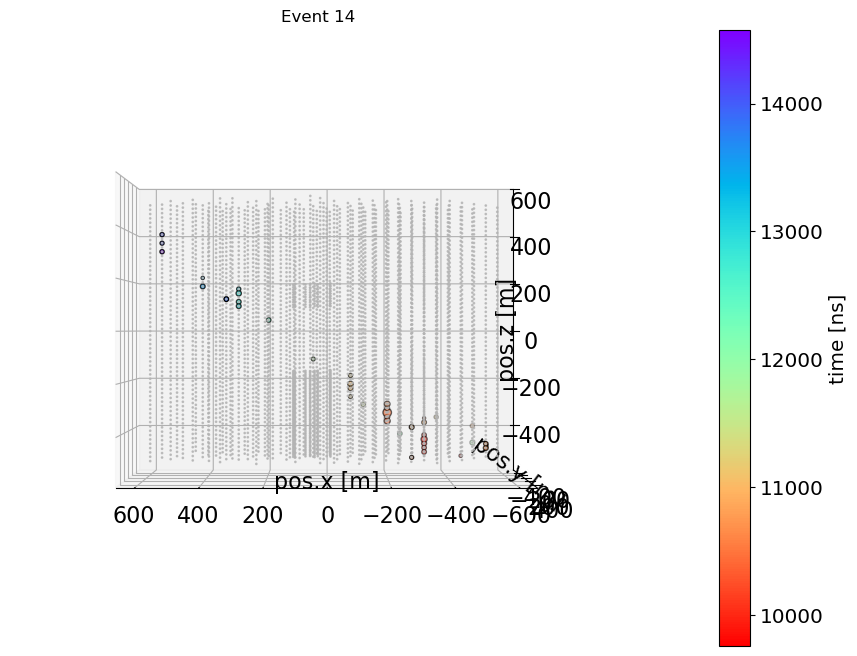

In [57]:
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'
geo = pd.read_csv(geo_file)

events_meta_file = os.path.join(PATH_TO_INPUT, META_FILE_NAME)
events_pulses_file = os.path.join(PATH_TO_INPUT, PULSES_FILE_NAME)
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'

events_meta = pd.read_feather(events_meta_file)
events_data = pd.read_feather(events_pulses_file)
geo = pd.read_csv(geo_file)


int_cols_meta = ["event_id", "idx_start", "idx_end", "n_channel_HLC", "n_channel"]
events_meta[int_cols_meta] = events_meta[int_cols_meta].astype("Int64")

int_cols_data = ["event_id", "sensor_id", "is_HLC"]
events_data[int_cols_data] = events_data[int_cols_data].astype("Int64")

meta, pulses = get_event_data(EVENT_INDEX)
print(f"muon energy: {meta['muon_energy_at_detector']/1.e3:.1f} TeV")

# Get dom locations, first hit times, and total charges (for each dom).
event_data = get_per_dom_summary_from_sim_data(meta, pulses)
print("length of event data:", len(event_data))
print("length of pulses data:", len(pulses))
# Remove early pulses.
replace_early_pulse(event_data, pulses)
print("n_doms", len(event_data))

# Get MCTruth.
true_pos = jnp.array([meta['muon_pos_x'], meta['muon_pos_y'], meta['muon_pos_z']])
print(true_pos)
true_time = meta['muon_time']
true_zenith = meta['muon_zenith']
true_azimuth = meta['muon_azimuth']
true_src = jnp.array([true_zenith, true_azimuth])
true_src_deg = np.rad2deg(true_src)
print("true direction:", true_src)
print("true direction:", true_src_deg)
print("length of event data:", len(event_data))
splinempe_zenith = meta['spline_mpe_zenith']
splinempe_azimuth = meta['spline_mpe_azimuth']
spline_src = jnp.array([splinempe_zenith, splinempe_azimuth])

plot_event(event_data, EVENT_INDEX, geo=geo)

/tmp/ipykernel_2778444/3728822468.py:131: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=12)


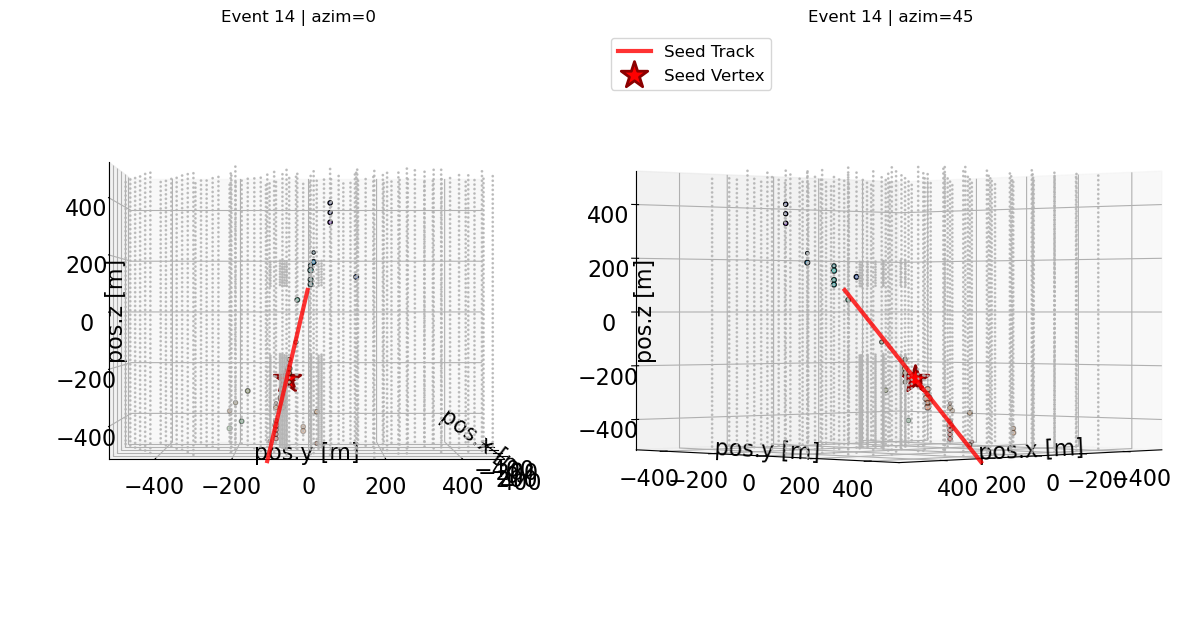

In [58]:
seed_pos, seed_time, _, seed_src = linefit(event_data)
seed_pos  = jnp.asarray(seed_pos)      # (3,)
seed_time = jnp.asarray(seed_time)     # scalar ()
seed_src  = jnp.asarray(seed_src)      # (2,)



plot_event_new(event_data, EVENT_INDEX, geo=geo, seed_pos=seed_pos, seed_time=seed_time, seed_direction=seed_src, track_length=1000, azims=(0, 45), elev=0)

In [59]:
network_path = '/mnt/scratch/baburish/TPN-training/a_new/hans_data_weights/new_model_no_penalties_tree_start_epoch_100.eqx'
eval_network_v = get_network_eval_v_fn_f32(bpath=network_path, dtype=dtype, n_hidden=n_hidden)
eval_network_doms_and_track = get_eval_network_doms_and_track(eval_network_v, dtype=dtype, gupta=gupta, n_comp=n_comp)


shifting seed vertex.

Starting fit with Gaussian convolution width: 100 ns
Initial fit: logl 485.816

Starting fit with Gaussian convolution width: 10 ns
Accepted update: logl improved by 108.865

Starting fit with Gaussian convolution width: 3.0 ns
Accepted update: logl improved by 27.284
Sigma 3.0: 10.48s
Reconstructed vs True Angular Distance error 0.43 deg
SplineMPE vs True Angular Distance error 0.34 deg


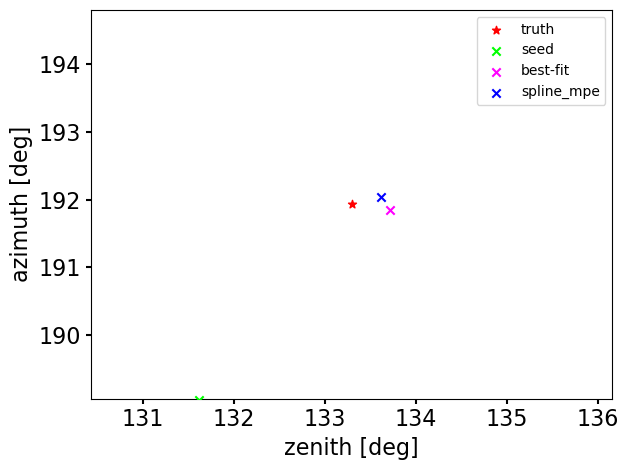

In [60]:
track_pos, track_time, _, track_src = linefit(event_data)
track_pos  = jnp.asarray(track_pos)      # (3,)
track_time = jnp.asarray(track_time)     # scalar ()
track_src  = jnp.asarray(track_src)      # (2,)

center_track_seed = True

centered_track_pos, centered_track_time = track_pos, track_time
if center_track_seed:
    print("shifting seed vertex.")
    centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)

# print("seed vertex:", centered_track_pos, "m")

fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
# print(fitting_event_data.shape)


GAUS_CONV_WIDTH = [100, 10, 3.0]
best_logl = None
t_total_warm = 0
best_logl = None
sigma_times_warm = []
start = time.time()
for sigma in GAUS_CONV_WIDTH:
    print(f"\nStarting fit with Gaussian convolution width: {sigma} ns")
    neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=sigma)
    fit_llh = get_fitter(neg_llh, use_multiple_vertex_seeds=True, prescan_time=False)#, rtol=1e-16, atol=1e-14)
    fit_llh_jit = jax.jit(fit_llh)
    
    if best_logl is not None:
        seed_src = best_direction
        seed_pos = best_vertex
        seed_time = best_time
    else:
        seed_src = track_src
        seed_pos = centered_track_pos
        seed_time = centered_track_time
    
    solution = fit_llh_jit(seed_src, seed_pos, seed_time, fitting_event_data)
    current_logl, current_direction, current_vertex, current_time = solution

    if best_logl is None:
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
        accepted = True
        print(f"Initial fit: logl {current_logl:.3f}")
        continue  
    # print(f"\nGaussian convolution width: {sigma} ns")
    # print(f"Current logl: {current_logl:.3f}")
    # print(f"Best logl: {best_logl:.3f}")
    delta_logl = -2*(current_logl - best_logl)
    if meta['q_tot'] > 100:
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
    else:
        if sigma <= 2:
            best_logl = current_logl
            best_direction = current_direction
            best_vertex = current_vertex
            best_time = current_time
            accepted = True
        elif delta_logl > 6:  # 90% confidence improvement threshold for 2 dof
            best_logl = current_logl
            best_direction = current_direction
            best_vertex = current_vertex
            best_time = current_time
            accepted = True
            print(f"Accepted update: logl improved by {delta_logl:.3f}")

        else:
            print(f"Rejected update: logl improved by {delta_logl:.3f}")
            accepted = False


elapsed = time.time() - start
print(f"Sigma {sigma}: {elapsed:.2f}s")
best_direction_deg = np.rad2deg(best_direction)
spline_src_deg = np.rad2deg(spline_src)
linefit_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    best_direction_deg[0], best_direction_deg[1]
)
splinempe_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    spline_src_deg[0], spline_src_deg[1]
)
print(f"Reconstructed vs True Angular Distance error {linefit_ang_err:.2f} deg")
print(f"SplineMPE vs True Angular Distance error {splinempe_ang_err:.2f} deg")

scan_llh = get_scanner(
                        neg_llh,
                        use_multiple_vertex_seeds=True,
                        prescan_time=False,
                        n_splits=25,
                        use_jit=True
                    )

zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
X, Y = jnp.meshgrid(zenith, azimuth)
fig, ax = plt.subplots()

plot_scan = False
if plot_scan:
    print("running the scan.")
    solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)

    sol_logl, sol_vertex, sol_time = solution
    logls = sol_logl.reshape(X.shape)
    points = np.column_stack([X.flatten(), Y.flatten()])
    values = logls.flatten()
    logl_best_dir = griddata(points, values, 
                             (best_direction[0], best_direction[1]), 
                             method='cubic')
    delta_logl_best_dir = logl_best_dir - np.amin(logls)
    logl_spline = griddata(points, values, 
                          (spline_src[0], spline_src[1]), 
                          method='cubic')
    delta_logl_spline = logl_spline - np.amin(logls)
    
    print(f"\nLikelihood at best_direction: {logl_best_dir:.6f}")
    print(f"ΔlogL at best_direction: {delta_logl_best_dir:.6f}")
    print(f"\nLikelihood at spline_src: {logl_spline:.6f}")
    print(f"ΔlogL at spline_src: {delta_logl_spline:.6f}")
    # Plot.

    min_logl = np.amin(logls)
    delta_logl = logls - np.amin(logls)
    pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
    cbar = fig.colorbar(pc)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.get_yaxis().labelpad = 5
    cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
    cbar.outline.set_linewidth(1.5)

    contours = [4.61]
    ix1, ix2 = np.where(delta_logl==0)
    ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
    ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)
ax.scatter(np.rad2deg(spline_src[0]), np.rad2deg(spline_src[1]), marker="x", color='blue', label="spline_mpe", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))

ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
plt.legend()
plt.tight_layout()

plt.show()


In [61]:
network_path = '/mnt/scratch/baburish/TPN-training/gupta_mixture_jax/new_weights/4comp_no_penalties_w4096batch_tree_start_epoch_255.eqx'
eval_network_v = get_network_eval_v_fn_f32(bpath=network_path, dtype=dtype, n_hidden=n_hidden)
eval_network_doms_and_track = get_eval_network_doms_and_track(eval_network_v, dtype=dtype, gupta=gupta, n_comp=n_comp)


shifting seed vertex.

Starting fit with Gaussian convolution width: 100 ns
Initial fit: logl 485.847

Starting fit with Gaussian convolution width: 10 ns
Accepted update: logl improved by 109.301

Starting fit with Gaussian convolution width: 3.0 ns
Accepted update: logl improved by 27.555
Sigma 3.0: 10.29s
Reconstructed vs True Angular Distance error 0.42 deg
SplineMPE vs True Angular Distance error 0.34 deg


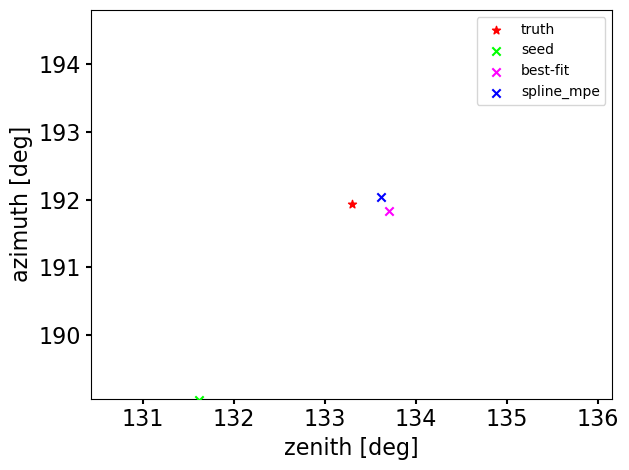

In [62]:
track_pos, track_time, _, track_src = linefit(event_data)
track_pos  = jnp.asarray(track_pos)      # (3,)
track_time = jnp.asarray(track_time)     # scalar ()
track_src  = jnp.asarray(track_src)      # (2,)

# print("original seed vertex:", np.rad2deg(true_src), "m")
# print("seed direction:", np.rad2deg(track_src), "deg")
# print("Weighted vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(track_src[0]))**2+(true_src_deg[1]-np.rad2deg(track_src[1]))**2))
# print("spline_mpe position:", jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']]))
# print("spline_mpe time:", meta['spline_mpe_time'])


center_track_seed = True

centered_track_pos, centered_track_time = track_pos, track_time
if center_track_seed:
    print("shifting seed vertex.")
    centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)

# print("seed vertex:", centered_track_pos, "m")

fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
# print(fitting_event_data.shape)


GAUS_CONV_WIDTH = [100, 10, 3.0]
best_logl = None
t_total_warm = 0
best_logl = None
sigma_times_warm = []
start = time.time()
for sigma in GAUS_CONV_WIDTH:
    print(f"\nStarting fit with Gaussian convolution width: {sigma} ns")
    neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=sigma)
    fit_llh = get_fitter(neg_llh, use_multiple_vertex_seeds=True, prescan_time=False)#, rtol=1e-16, atol=1e-14)
    fit_llh_jit = jax.jit(fit_llh)
    
    if best_logl is not None:
        seed_src = best_direction
        seed_pos = best_vertex
        seed_time = best_time
    else:
        seed_src = track_src
        seed_pos = centered_track_pos
        seed_time = centered_track_time
    
    solution = fit_llh_jit(seed_src, seed_pos, seed_time, fitting_event_data)
    current_logl, current_direction, current_vertex, current_time = solution

    if best_logl is None:
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
        accepted = True
        print(f"Initial fit: logl {current_logl:.3f}")
        continue  
    # print(f"\nGaussian convolution width: {sigma} ns")
    # print(f"Current logl: {current_logl:.3f}")
    # print(f"Best logl: {best_logl:.3f}")
    delta_logl = -2*(current_logl - best_logl)
    if meta['q_tot'] > 100:
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
    else:
        if sigma <= 2:
            best_logl = current_logl
            best_direction = current_direction
            best_vertex = current_vertex
            best_time = current_time
            accepted = True
        elif delta_logl > 6:  # 90% confidence improvement threshold for 2 dof
            best_logl = current_logl
            best_direction = current_direction
            best_vertex = current_vertex
            best_time = current_time
            accepted = True
            print(f"Accepted update: logl improved by {delta_logl:.3f}")

        else:
            print(f"Rejected update: logl improved by {delta_logl:.3f}")
            accepted = False
    

elapsed = time.time() - start
print(f"Sigma {sigma}: {elapsed:.2f}s")
best_direction_deg = np.rad2deg(best_direction)
spline_src_deg = np.rad2deg(spline_src)
linefit_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    best_direction_deg[0], best_direction_deg[1]
)
splinempe_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    spline_src_deg[0], spline_src_deg[1]
)
print(f"Reconstructed vs True Angular Distance error {linefit_ang_err:.2f} deg")
print(f"SplineMPE vs True Angular Distance error {splinempe_ang_err:.2f} deg")


scan_llh = get_scanner(
                        neg_llh,
                        use_multiple_vertex_seeds=True,
                        prescan_time=False,
                        n_splits=25,
                        use_jit=True
                    )

zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
X, Y = jnp.meshgrid(zenith, azimuth)
fig, ax = plt.subplots()

plot_scan = False
if plot_scan:
    print("running the scan.")
    solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)

    sol_logl, sol_vertex, sol_time = solution
    logls = sol_logl.reshape(X.shape)
    points = np.column_stack([X.flatten(), Y.flatten()])
    values = logls.flatten()
    logl_best_dir = griddata(points, values, 
                             (best_direction[0], best_direction[1]), 
                             method='cubic')
    delta_logl_best_dir = logl_best_dir - np.amin(logls)
    logl_spline = griddata(points, values, 
                          (spline_src[0], spline_src[1]), 
                          method='cubic')
    delta_logl_spline = logl_spline - np.amin(logls)
    
    print(f"\nLikelihood at best_direction: {logl_best_dir:.6f}")
    print(f"ΔlogL at best_direction: {delta_logl_best_dir:.6f}")
    print(f"\nLikelihood at spline_src: {logl_spline:.6f}")
    print(f"ΔlogL at spline_src: {delta_logl_spline:.6f}")
    # Plot.

    min_logl = np.amin(logls)
    delta_logl = logls - np.amin(logls)
    pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
    cbar = fig.colorbar(pc)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.get_yaxis().labelpad = 5
    cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
    cbar.outline.set_linewidth(1.5)

    contours = [4.61]
    ix1, ix2 = np.where(delta_logl==0)
    ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
    ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)
ax.scatter(np.rad2deg(spline_src[0]), np.rad2deg(spline_src[1]), marker="x", color='blue', label="spline_mpe", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))

ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
plt.legend()
plt.tight_layout()

plt.show()


In [52]:

# track_pos = jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']])
# track_time = meta['spline_mpe_time']
# track_zenith = meta['spline_mpe_zenith']
# track_azimuth = meta['spline_mpe_azimuth']
# track_src = jnp.array([track_zenith, track_azimuth])

# # print("original seed vertex:", np.rad2deg(true_src), "m")
# # print("seed direction:", np.rad2deg(track_src), "deg")
# # print("Weighted vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(track_src[0]))**2+(true_src_deg[1]-np.rad2deg(track_src[1]))**2))
# # print("spline_mpe position:", jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']]))
# # print("spline_mpe time:", meta['spline_mpe_time'])


# center_track_seed = True

# centered_track_pos, centered_track_time = track_pos, track_time
# if center_track_seed:
#     print("shifting seed vertex.")
#     centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)

# # print("seed vertex:", centered_track_pos, "m")

# fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
# # print(fitting_event_data.shape)


# GAUS_CONV_WIDTH = [3.0]
# best_logl = None
# t_total_warm = 0
# best_logl = None
# sigma_times_warm = []
# start = time.time()
# for sigma in GAUS_CONV_WIDTH:
#     print(f"\nStarting fit with Gaussian convolution width: {sigma} ns")
#     neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=sigma)
#     fit_llh = get_fitter(neg_llh, use_multiple_vertex_seeds=True, prescan_time=False)#, rtol=1e-16, atol=1e-14)
#     fit_llh_jit = jax.jit(fit_llh)
    
#     if best_logl is not None:
#         seed_src = best_direction
#         seed_pos = best_vertex
#         seed_time = best_time
#     else:
#         seed_src = track_src
#         seed_pos = centered_track_pos
#         seed_time = centered_track_time
    
#     solution = fit_llh_jit(seed_src, seed_pos, seed_time, fitting_event_data)
#     current_logl, current_direction, current_vertex, current_time = solution

#     if best_logl is None:
#         best_logl = current_logl
#         best_direction = current_direction
#         best_vertex = current_vertex
#         best_time = current_time
#         accepted = True
#         print(f"Initial fit: logl {current_logl:.3f}")
#         continue  
#     # print(f"\nGaussian convolution width: {sigma} ns")
#     # print(f"Current logl: {current_logl:.3f}")
#     # print(f"Best logl: {best_logl:.3f}")
#     delta_logl = -2*(current_logl - best_logl)
#     if meta['q_tot'] > 100:
#         best_logl = current_logl
#         best_direction = current_direction
#         best_vertex = current_vertex
#         best_time = current_time
#     else:
#         if sigma <= 2:
#             best_logl = current_logl
#             best_direction = current_direction
#             best_vertex = current_vertex
#             best_time = current_time
#             accepted = True
#         elif delta_logl > 16:  # 90% confidence improvement threshold for 2 dof
#             best_logl = current_logl
#             best_direction = current_direction
#             best_vertex = current_vertex
#             best_time = current_time
#             accepted = True
#             print(f"Accepted update: logl improved by {delta_logl:.3f}")

#         else:
#             print(f"Rejected update: logl improved by {delta_logl:.3f}")
#             accepted = False
    
    
#     print(f"Accepted update: {accepted}")

#     print("Reconstructed vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(best_direction[0]))**2+(true_src_deg[1]-np.rad2deg(best_direction[1]))**2))

#     print("SplineMPE vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(spline_src[0]))**2+(true_src_deg[1]-np.rad2deg(spline_src[1]))**2))

#     print("Seed vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(seed_src[0]))**2+(true_src_deg[1]-np.rad2deg(seed_src[1]))**2))

#     print("Seed vs Reconstructed Angular Distance error", np.sqrt((np.rad2deg(best_direction[0]-seed_src[0]))**2+(np.rad2deg(best_direction[1]-seed_src[1]))**2))

# elapsed = time.time() - start
# print(f"Sigma {sigma}: {elapsed:.2f}s")
# print(f"Sigma {sigma}: {elapsed:.2f}s")
# best_direction_deg = np.rad2deg(best_direction)
# spline_src_deg = np.rad2deg(spline_src)
# linefit_ang_err = angular_separation_deg(
#     true_src_deg[0], true_src_deg[1],
#     best_direction_deg[0], best_direction_deg[1]
# )
# splinempe_ang_err = angular_separation_deg(
#     true_src_deg[0], true_src_deg[1],
#     spline_src_deg[0], spline_src_deg[1]
# )
# print("Reconstructed vs True Angular Distance error", linefit_ang_err)
# print("SplineMPE vs True Angular Distance error", splinempe_ang_err)
# scan_llh = get_scanner(
#                         neg_llh,
#                         use_multiple_vertex_seeds=True,
#                         prescan_time=False,
#                         n_splits=25,
#                         use_jit=True
#                     )

# zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
# azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
# X, Y = jnp.meshgrid(zenith, azimuth)
# fig, ax = plt.subplots()

# plot_scan = True
# if plot_scan:
#     print("running the scan.")
#     solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)

#     sol_logl, sol_vertex, sol_time = solution
#     logls = sol_logl.reshape(X.shape)
#     points = np.column_stack([X.flatten(), Y.flatten()])
#     values = logls.flatten()
#     logl_best_dir = griddata(points, values, 
#                              (best_direction[0], best_direction[1]), 
#                              method='cubic')
#     delta_logl_best_dir = logl_best_dir - np.amin(logls)
#     logl_spline = griddata(points, values, 
#                           (spline_src[0], spline_src[1]), 
#                           method='cubic')
#     delta_logl_spline = logl_spline - np.amin(logls)
    
#     print(f"\nLikelihood at best_direction: {logl_best_dir:.6f}")
#     print(f"ΔlogL at best_direction: {delta_logl_best_dir:.6f}")
#     print(f"\nLikelihood at spline_src: {logl_spline:.6f}")
#     print(f"ΔlogL at spline_src: {delta_logl_spline:.6f}")
#     # Plot.

#     min_logl = np.amin(logls)
#     delta_logl = logls - np.amin(logls)
#     pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
#     cbar = fig.colorbar(pc)
#     cbar.ax.tick_params(labelsize=16)
#     cbar.ax.get_yaxis().labelpad = 5
#     cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
#     cbar.outline.set_linewidth(1.5)

#     contours = [4.61]
#     ix1, ix2 = np.where(delta_logl==0)
#     ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
#     ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

# ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
# ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
# ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)
# ax.scatter(np.rad2deg(spline_src[0]), np.rad2deg(spline_src[1]), marker="x", color='blue', label="spline_mpe", zorder=200)

# ax.set_xlabel("zenith [deg]", fontsize=16)
# ax.set_ylabel("azimuth [deg]", fontsize=16)
# ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
# ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))

# ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)

# plt.legend()
# plt.tight_layout()

# plt.show()
